In [1]:
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

In [2]:
import argparse
import pandas as pd
import lightgbm as lgb
import joblib
from sklearn.preprocessing import StandardScaler
import copy
# import random
import itertools
from sklearn.impute import SimpleImputer
import numpy as np

In [3]:
def preprocess_data(df):
    # # 假设需要对数据进行标准化
    # scaler = StandardScaler()
    # data_scaled = scaler.fit_transform(data)
    # Count the frequency of k-mer in each RNA sequence
        # k-mer was normalized by total k-mer count of each RNA sequence
    def _count_kmer(Dataset, k):  # k = 3, 4, 5
        
        # copy dataset
        dataset = copy.deepcopy(Dataset)
        # alphabet of nucleotide
        nucleotide = ['A', 'C', 'G', 'T']
        
        # generate k-mers
        #  k == 5:
        five = list(itertools.product(nucleotide, repeat=5))
        pentamer = [''.join(n) for n in five]
        
        #  k == 4:
        four = list(itertools.product(nucleotide, repeat=4))
        tetramer = [''.join(n) for n in four]

        # k == 3:
        three = list(itertools.product(nucleotide, repeat=3))
        threemer = [''.join(n) for n in three]
        
        # input features can be combinations of different k values
        if k == 34:
            table_kmer = dict.fromkeys(threemer, 0)
            table_kmer.update(dict.fromkeys(tetramer, 0))
        elif k == 45:
            table_kmer = dict.fromkeys(tetramer, 0)
            table_kmer.update(dict.fromkeys(pentamer, 0))
        elif k == 345:
            table_kmer = dict.fromkeys(threemer, 0)
            table_kmer.update(dict.fromkeys(tetramer, 0))
            table_kmer.update(dict.fromkeys(pentamer, 0))

        # count k-mer for each sequence
        for mer in table_kmer.keys():
            table_kmer[mer] = dataset["sequence"].apply(lambda x: x.count(mer))
        
        # for k-mer raw count without normalization, index: nuc:1 or cyto:0
        rawcount_kmer_df = pd.DataFrame(table_kmer)
        df1_rawcount = pd.concat([rawcount_kmer_df, dataset["name"]], axis=1)
        df1_rawcount.index = dataset["tag"]

        # for k-mer frequency with normalization, index: nuc:1 or cyto:0
        freq_kmer_df = rawcount_kmer_df.apply(lambda x: x / x.sum(), axis=1)
        df1 = pd.concat([freq_kmer_df, dataset["name"]], axis=1)
        df1.index = dataset["tag"]

        return df1, df1_rawcount

    df_kmer_test, df_kmer_test_raw = _count_kmer(df, 345)
    del df_kmer_test['name']
    x_kmer = df_kmer_test.values
    imputer = SimpleImputer(strategy='mean')
    x_test = imputer.fit_transform(x_kmer)
    # y_test = np.array(df_kmer_test.index)

    return x_test

In [4]:
def load_model(model_path):
    model = joblib.load(model_path)
    return model

In [5]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, average_precision_score, matthews_corrcoef

def predict(model, x_test, df):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]
    df['prediction'] = y_pred  # 添加预测标签列
    df['prob'] = y_prob  # 添加预测概率列

    evaluate_df = df

    auroc = roc_auc_score(evaluate_df["tag"], evaluate_df["prob"])
    auprc = average_precision_score(evaluate_df["tag"], evaluate_df["prob"])
    accuracy = accuracy_score(evaluate_df['tag'], evaluate_df['prediction'])
    f1 = f1_score(evaluate_df['tag'], evaluate_df['prediction'])
    mcc = matthews_corrcoef(evaluate_df['tag'], evaluate_df['prediction'])
    recall = recall_score(evaluate_df['tag'], evaluate_df['prediction'])
    precision = precision_score(evaluate_df['tag'], evaluate_df['prediction'])
    print(f"AUROC: {auroc:.4f}")
    print(f"AUPRC: {auprc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    
    return evaluate_df

In [6]:
def parse_fasta_to_dataframe(fasta_path):
    records = []
    with open(fasta_path, 'r') as file:
        name, tag, sum_EVP, read_val, seq_lines = None, None, None, None, []
        for line in file:
            line = line.strip()
            if line.startswith('>'):
                if name:
                    sequence = ''.join(seq_lines)
                    records.append({'name': name, 'tag': tag, 'sum_EVP': sum_EVP, 'read': read_val, 'sequence': sequence})
                
                header = line[1:]
                # 仅根据最右侧的下划线进行分割提取 tag
                parts = header.rsplit('_', 1)
                if len(parts) >= 2:
                    name = parts[0]
                    try:
                        tag = int(parts[-1])
                        sum_EVP, read_val = 0.0, 0.0  # 未提供的情况下给定默认值
                    except ValueError:
                        sum_EVP, read_val, tag = 0.0, 0.0, None
                else:
                    name = header
                    sum_EVP, read_val, tag = 0.0, 0.0, None
                seq_lines = []
            else:
                seq_lines.append(line)
                
        # 添加最后一条记录
        if name:
            sequence = ''.join(seq_lines)
            records.append({'name': name, 'tag': tag, 'sum_EVP': sum_EVP, 'read': read_val, 'sequence': sequence})
    
    return pd.DataFrame(records)

In [7]:
# 尝试预测lncRNA
model = load_model('/lulabdata3/huangkeyun/zhangys/RNA_locator/circExor/models/saved_models/circRNA_ML_Model_tridivided_Output/RandomForest/best_RandomForest_model.pkl')
df = parse_fasta_to_dataframe('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/linearRNA/linearDataSet/lncRNA_balanced_dataset.fa')
df = df[(df['sequence'].str.len() >= 1000) & (df['sequence'].str.len() <= 5000)].reset_index(drop=True)

x_test = preprocess_data(df)
evaluate_df = predict(model, x_test, df)


AUROC: 0.5107
AUPRC: 0.4819
Accuracy: 0.5141
F1 Score: 0.4143
MCC: 0.0113
Recall: 0.3666
Precision: 0.4762


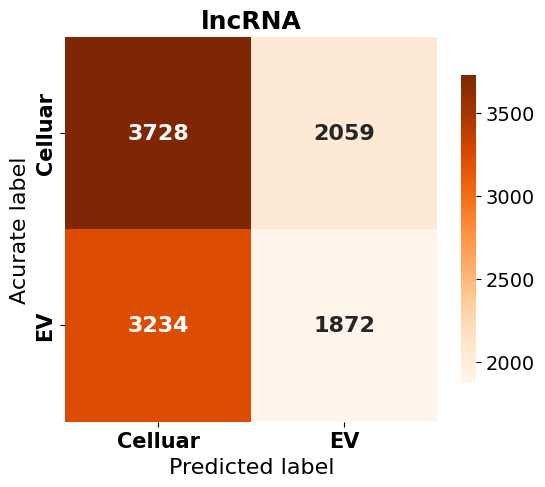

In [8]:
cm = confusion_matrix(evaluate_df['tag'], evaluate_df['prediction'])

# 使用 seaborn 绘制混淆矩阵
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                 xticklabels=['Celluar', 'EV'], yticklabels=['Celluar', 'EV'],
                 annot_kws={'size': 16, 'weight': 'bold'},  # 调整内部数字的字体大小和加粗
                 cbar_kws={'shrink': 0.8})  # 可选：调整colorbar大小

plt.title('lncRNA', fontsize=18, fontweight='bold')
plt.ylabel('Acurate label', fontsize=16)
plt.xlabel('Predicted label', fontsize=16)
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

# 调整右侧colorbar图例数字的字体大小
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # 调整colorbar刻度标签字体大小

plt.show()

In [9]:

#尝试预测EV gain lncRNA
model = load_model('/lulabdata3/huangkeyun/zhangys/RNA_locator/circExor/models/saved_models/circRNA_ML_Model_tridivided_Output/RandomForest/best_RandomForest_model.pkl')
df = parse_fasta_to_dataframe('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/linearRNA/EV-kmer_mutation/lncRNA_EV_gain_mutated.fasta')
df = df[(df['sequence'].str.len() >= 1000) & (df['sequence'].str.len() <= 5000)].reset_index(drop=True)

x_test = preprocess_data(df)
evaluate_df = predict(model, x_test, df)


AUROC: 0.5869
AUPRC: 0.5356
Accuracy: 0.5577
F1 Score: 0.4927
MCC: 0.1051
Recall: 0.4592
Precision: 0.5314


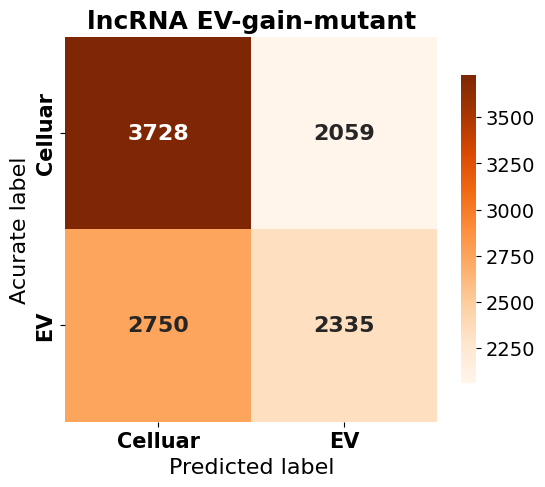

In [10]:
cm = confusion_matrix(evaluate_df['tag'], evaluate_df['prediction'])

# 使用 seaborn 绘制混淆矩阵
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                 xticklabels=['Celluar', 'EV'], yticklabels=['Celluar', 'EV'],
                 annot_kws={'size': 16, 'weight': 'bold'},  # 调整内部数字的字体大小和加粗
                 cbar_kws={'shrink': 0.8})  # 可选：调整colorbar大小

plt.title('lncRNA EV-gain-mutant', fontsize=18, fontweight='bold')
plt.ylabel('Acurate label', fontsize=16)
plt.xlabel('Predicted label', fontsize=16)
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

# 调整右侧colorbar图例数字的字体大小
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # 调整colorbar刻度标签字体大小

plt.show()

In [11]:
# 进行lncRNA的EV突变
# 原始数据
df_orig = parse_fasta_to_dataframe('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/linearRNA/linearDataSet/lncRNA_balanced_dataset.fa')
df_orig = df_orig[(df_orig['sequence'].str.len() >= 1000) & (df_orig['sequence'].str.len() <= 5000)].reset_index(drop=True)
x_orig = preprocess_data(df_orig)
evaluate_df_orig = predict(model, x_orig, df_orig)

# EV 突变
df_ev_mut = parse_fasta_to_dataframe('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/linearRNA/EV-kmer_mutation/lncRNA_EV_gain_mutated.fasta')
df_ev_mut = df_ev_mut[(df_ev_mut['sequence'].str.len() >= 1000) & (df_ev_mut['sequence'].str.len() <= 5000)].reset_index(drop=True)
x_ev_mut = preprocess_data(df_ev_mut)
evaluate_df_ev_mut = predict(model, x_ev_mut, df_ev_mut)

AUROC: 0.5107
AUPRC: 0.4819
Accuracy: 0.5141
F1 Score: 0.4143
MCC: 0.0113
Recall: 0.3666
Precision: 0.4762
AUROC: 0.5869
AUPRC: 0.5356
Accuracy: 0.5577
F1 Score: 0.4927
MCC: 0.1051
Recall: 0.4592
Precision: 0.5314


Original EV samples: 5106
Mutated EV samples: 5085
Mann-Whitney U test p-value: 1.82e-39


/tmp/ipykernel_26060/61685325.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='Probability', data=df_violin_ev, inner='box', palette=color_option, width=0.6)


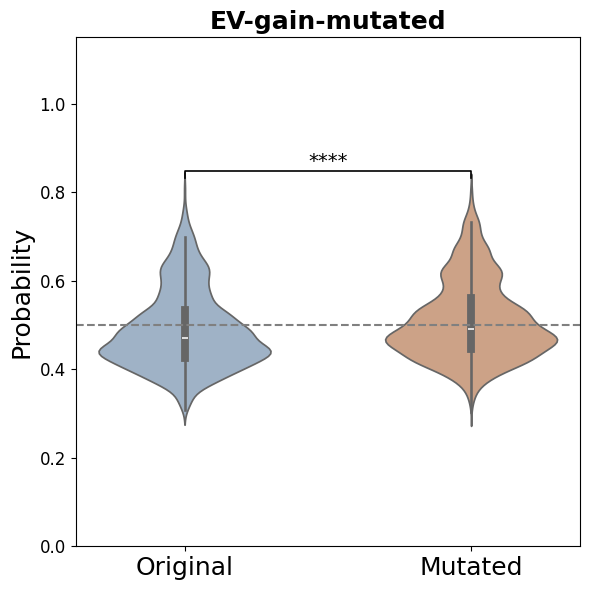

In [12]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 筛选正类样本（tag==1）
ev_orig = evaluate_df_orig[evaluate_df_orig['tag'] == 1]
ev_mut = evaluate_df_ev_mut[evaluate_df_ev_mut['tag'] == 1]

print(f"Original EV samples: {len(ev_orig)}")
print(f"Mutated EV samples: {len(ev_mut)}")

# # 构建 DataFrame 供绘图（去掉Condition字样）
# df_violin_ev = pd.DataFrame({
#     'Original': ev_orig['prob'].values,
#     'Mutated': ev_mut['prob'].values
# })
# df_violin_ev = df_violin_ev.melt(var_name='Group', value_name='Probability')

# 直接构建长格式 DataFrame 供绘图，避免长度不一致报错
df_orig_plot = pd.DataFrame({
    'Group': ['Original'] * len(ev_orig),
    'Probability': ev_orig['prob'].values
})

df_mut_plot = pd.DataFrame({
    'Group': ['Mutated'] * len(ev_mut),
    'Probability': ev_mut['prob'].values
})

df_violin_ev = pd.concat([df_orig_plot, df_mut_plot], ignore_index=True)

# 计算显著性检验 (Mann-Whitney U test)
stat, p_value = stats.mannwhitneyu(ev_orig['prob'].values, ev_mut['prob'].values, alternative='two-sided')
print(f"Mann-Whitney U test p-value: {p_value:.2e}")

def get_asterisks_for_pval(p_val):
    if p_val > 0.05:
        return 'ns'
    elif p_val <= 0.0001:
        return '****'
    elif p_val <= 0.001:
        return '***'
    elif p_val <= 0.01:
        return '**'
    elif p_val <= 0.05:
        return '*'

color_option = ['#98B2CD', '#D89F7B']
# 绘图
plt.figure(figsize=(6, 6))
ax = sns.violinplot(x='Group', y='Probability', data=df_violin_ev, inner='box', palette=color_option, width=0.6)

# --- 添加组间显著性检验标注 ---
ast = get_asterisks_for_pval(p_value)
x1, x2 = 0, 1
max_val = max(ev_orig['prob'].max(), ev_mut['prob'].max())
y = max_val + 0.02
h = 0.015
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
plt.text((x1+x2)*.5, y+h, ast, ha='center', va='bottom', color='black', fontsize=14)
# ------------------------------

plt.title('EV-gain-mutated', fontsize=18, fontweight='bold')

# 调整X轴和Y轴刻度字体大小
ax.tick_params(axis='x', labelsize=18)  # X轴刻度字体大小
ax.tick_params(axis='y', labelsize=12)  # Y轴刻度字体大小

# 调整X轴和Y轴标题字体大小
ax.set_xlabel('', fontsize=16)  # X轴标题（这里设为空）
ax.set_ylabel('Probability', fontsize=18)  # Y轴标题字体大小

plt.axhline(0.5, linestyle='--', color='gray')
plt.ylim(0, 1.15) # 修改上限，在顶部留出空间显示显著性星号
plt.tight_layout()
plt.show()

In [13]:
# 进行mRNA的gain EV预测
# 原始数据
df_orig = parse_fasta_to_dataframe('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/linearRNA/linearDataSet/mRNA_balanced_dataset.fa')
df_orig = df_orig[df_orig['sequence'].str.len() < 500].reset_index(drop=True)
x_orig = preprocess_data(df_orig)
evaluate_df_orig = predict(model, x_orig, df_orig)



AUROC: 0.4924
AUPRC: 0.5208
Accuracy: 0.4899
F1 Score: 0.4051
MCC: -0.0066
Recall: 0.3331
Precision: 0.5168


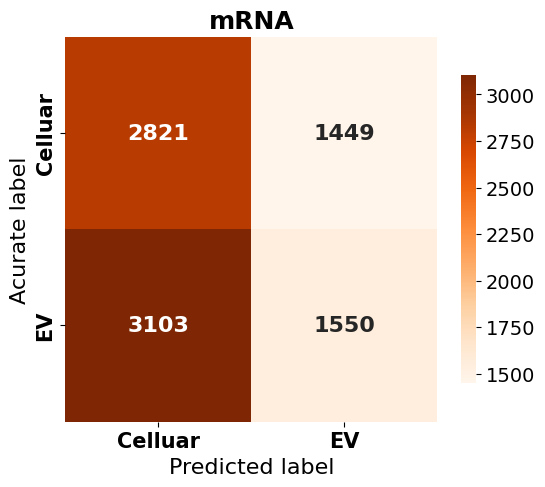

In [14]:
cm = confusion_matrix(evaluate_df_orig['tag'], evaluate_df_orig['prediction'])

# 使用 seaborn 绘制混淆矩阵
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                 xticklabels=['Celluar', 'EV'], yticklabels=['Celluar', 'EV'],
                 annot_kws={'size': 16, 'weight': 'bold'},  # 调整内部数字的字体大小和加粗
                 cbar_kws={'shrink': 0.8})  # 可选：调整colorbar大小

plt.title('mRNA', fontsize=18, fontweight='bold')
plt.ylabel('Acurate label', fontsize=16)
plt.xlabel('Predicted label', fontsize=16)
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

# 调整右侧colorbar图例数字的字体大小
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # 调整colorbar刻度标签字体大小

plt.show()

In [15]:
# EV 突变
df_ev_mut = parse_fasta_to_dataframe('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/linearRNA/EV-kmer_mutation/mRNA_EV_gain_mutated.fasta')
df_ev_mut = df_ev_mut[df_ev_mut['sequence'].str.len() < 500].reset_index(drop=True)
x_ev_mut = preprocess_data(df_ev_mut)
evaluate_df_ev_mut = predict(model, x_ev_mut, df_ev_mut)

AUROC: 0.5506
AUPRC: 0.5722
Accuracy: 0.5295
F1 Score: 0.4846
MCC: 0.0774
Recall: 0.4147
Precision: 0.5828


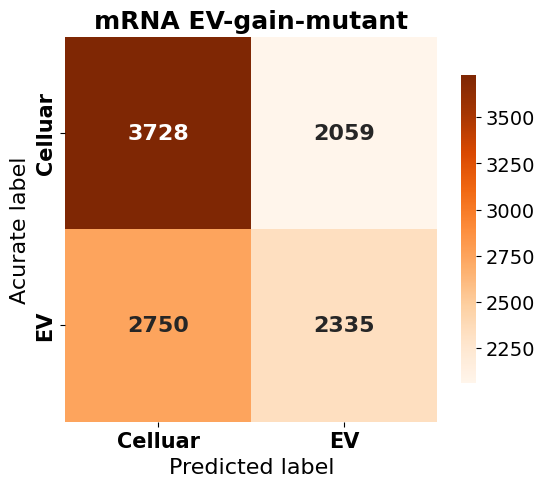

In [16]:
cm = confusion_matrix(evaluate_df['tag'], evaluate_df['prediction'])

# 使用 seaborn 绘制混淆矩阵
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                 xticklabels=['Celluar', 'EV'], yticklabels=['Celluar', 'EV'],
                 annot_kws={'size': 16, 'weight': 'bold'},  # 调整内部数字的字体大小和加粗
                 cbar_kws={'shrink': 0.8})  # 可选：调整colorbar大小

plt.title('mRNA EV-gain-mutant', fontsize=18, fontweight='bold')
plt.ylabel('Acurate label', fontsize=16)
plt.xlabel('Predicted label', fontsize=16)
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

# 调整右侧colorbar图例数字的字体大小
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # 调整colorbar刻度标签字体大小

plt.show()

Original EV samples: 4653
Mutated EV samples: 4881
Mann-Whitney U test p-value: 8.21e-22


/tmp/ipykernel_26060/2155042821.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='Probability', data=df_violin_ev, inner='box', palette=color_option, width=0.6)


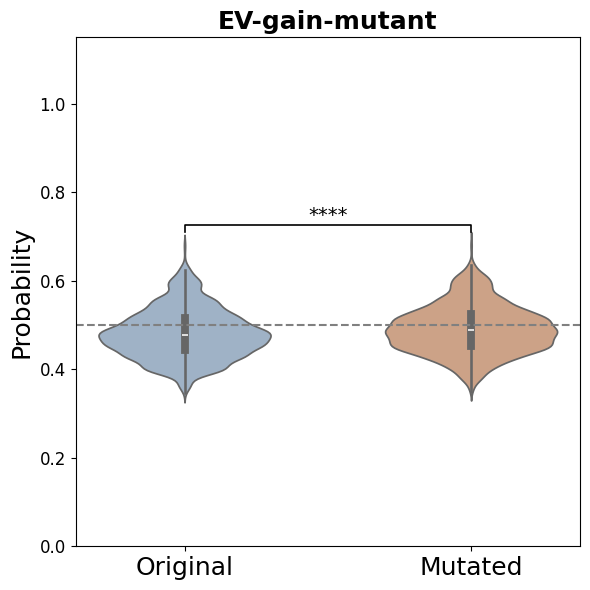

In [17]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 筛选正类样本（tag==1）
ev_orig = evaluate_df_orig[evaluate_df_orig['tag'] == 1]
ev_mut = evaluate_df_ev_mut[evaluate_df_ev_mut['tag'] == 1]

print(f"Original EV samples: {len(ev_orig)}")
print(f"Mutated EV samples: {len(ev_mut)}")

# # 构建 DataFrame 供绘图（去掉Condition字样）
# df_violin_ev = pd.DataFrame({
#     'Original': ev_orig['prob'].values,
#     'Mutated': ev_mut['prob'].values
# })
# df_violin_ev = df_violin_ev.melt(var_name='Group', value_name='Probability')

# 直接构建长格式 DataFrame 供绘图，避免长度不一致报错
df_orig_plot = pd.DataFrame({
    'Group': ['Original'] * len(ev_orig),
    'Probability': ev_orig['prob'].values
})

df_mut_plot = pd.DataFrame({
    'Group': ['Mutated'] * len(ev_mut),
    'Probability': ev_mut['prob'].values
})

df_violin_ev = pd.concat([df_orig_plot, df_mut_plot], ignore_index=True)

# 计算显著性检验 (Mann-Whitney U test)
stat, p_value = stats.mannwhitneyu(ev_orig['prob'].values, ev_mut['prob'].values, alternative='two-sided')
print(f"Mann-Whitney U test p-value: {p_value:.2e}")

def get_asterisks_for_pval(p_val):
    if p_val > 0.05:
        return 'ns'
    elif p_val <= 0.0001:
        return '****'
    elif p_val <= 0.001:
        return '***'
    elif p_val <= 0.01:
        return '**'
    elif p_val <= 0.05:
        return '*'

color_option = ['#98B2CD', '#D89F7B']
# 绘图
plt.figure(figsize=(6, 6))
ax = sns.violinplot(x='Group', y='Probability', data=df_violin_ev, inner='box', palette=color_option, width=0.6)

# --- 添加组间显著性检验标注 ---
ast = get_asterisks_for_pval(p_value)
x1, x2 = 0, 1
max_val = max(ev_orig['prob'].max(), ev_mut['prob'].max())
y = max_val + 0.02
h = 0.015
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
plt.text((x1+x2)*.5, y+h, ast, ha='center', va='bottom', color='black', fontsize=14)
# ------------------------------

plt.title('EV-gain-mutant', fontsize=18, fontweight='bold')

# 调整X轴和Y轴刻度字体大小
ax.tick_params(axis='x', labelsize=18)  # X轴刻度字体大小
ax.tick_params(axis='y', labelsize=12)  # Y轴刻度字体大小

# 调整X轴和Y轴标题字体大小
ax.set_xlabel('', fontsize=16)  # X轴标题（这里设为空）
ax.set_ylabel('Probability', fontsize=18)  # Y轴标题字体大小

plt.axhline(0.5, linestyle='--', color='gray')
plt.ylim(0, 1.15) # 修改上限，在顶部留出空间显示显著性星号
plt.tight_layout()
plt.show()